# Track demo — azimuth & distance from a single OBS

Two independent estimators on the same window, then the **initial extraction
method** applied to each:

1. **Azigram** (active-intensity bearing per time/frequency) → DBSCAN source
   extraction (`get_sources_azimuths`) → **azimuth curve**.
2. **Cepstrogram of the hydrophone only** (not oriented) → cepstral-peak
   clustering (`process_clustering_cepstro`) → quefrency→distance via the
   flat-bottom image model → **distance curve**.

In [1]:
# Self-contained: all signal-processing/extraction code lives in ./lib.
from lib.networkFuntions import *
from lib.signalProcessing import *
from lib.azimuthEstimateTools import get_sources_azimuths
from lib.distanceEstimateTools import (
    process_clustering_cepstro, get_source_possible_distances,
    get_distance_matrix_per_ref,
)

from obspy import UTCDateTime
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable

date_format = DateFormatter("%Y/%m/%d\n%H:%M")

In [2]:
# --- selection ---
net = "YV"
sta = "RR29"
dt1, dt2 = datetime(2013, 6, 6), datetime(2013, 6, 7)
dict_orientation = {"RR29": 267.5}          # sensor heading (deg)
sds_path = "./data/SDS"

In [3]:
dfstations = get_network_details(net, f"{sds_path}/INVENTORIES")
dfstations.set_index("sta", inplace=True)
dfstations

,net,net_start,net_end,lon,lat,ele,cha,sample_rate,sensitivity,starttime,endtime
sta,,,,,,,,,,,
RR01,YV,2011-01-01,2016-12-31 23:59:59,55.4230,-20.0069,-4298.0,BHZ,50.0,739666000.0,2012-10-05 04:53:07,2013-11-07 00:08:27
RR01,YV,2011-01-01,2016-12-31 23:59:59,55.4230,-20.0069,-4298.0,BDH,50.0,2008.5,2012-10-05 04:53:07,2013-11-07 00:08:27
RR01,YV,2011-01-01,2016-12-31 23:59:59,55.4230,-20.0069,-4298.0,BH2,50.0,742653000.0,2012-10-05 04:53:07,2013-11-07 00:08:27
RR01,YV,2011-01-01,2016-12-31 23:59:59,55.4230,-20.0069,-4298.0,BH1,50.0,753854000.0,2012-10-05 04:53:07,2013-11-07 00:08:27
RR02,YV,2011-01-01,2016-12-31 23:59:59,54.4984,-20.3392,-4436.0,BHZ,50.0,745640000.0,2012-10-03 15:34:32,2012-10-05 21:30:27
...,...,...,...,...,...,...,...,...,...,...,...
RR56,YV,2011-01-01,2016-12-31 23:59:59,59.5853,-21.9694,-4230.0,BH1,50.0,744893000.0,2012-10-20 17:27:45,2013-06-29 21:55:33
RR57,YV,2011-01-01,2016-12-31 23:59:59,58.0496,-24.7264,-5200.0,BDH,50.0,2008.5,2012-10-21 08:46:48,2013-10-31 19:56:14
RR57,YV,2011-01-01,2016-12-31 23:59:59,58.0496,-24.7264,-5200.0,BH1,50.0,731078000.0,2012-10-21 08:46:48,2013-10-31 19:56:14


In [4]:
stream = get_stream_for_selected_period(
    sds_root=sds_path, network=net, station=sta,
    channel='*', location='*',
    starttime=UTCDateTime(dt1), endtime=UTCDateTime(dt2))
stream = get_calibrated_stream(stream, dfstations)

# Trim to the common time span across components.
t0 = max(tr.stats.starttime for tr in stream)
t1 = min(tr.stats.endtime for tr in stream)
stream.trim(starttime=t0, endtime=t1)
print(stream)

4 Trace(s) in Stream:
YV.RR29.00.BDH | 2013-06-06T00:00:00.006500Z - 2013-06-06T23:59:59.990500Z | 62.5 Hz, 5400000 samples (masked)
YV.RR29.00.BH1 | 2013-06-06T00:00:00.006500Z - 2013-06-06T23:59:59.990500Z | 62.5 Hz, 5400000 samples (masked)
YV.RR29.00.BH2 | 2013-06-06T00:00:00.006500Z - 2013-06-06T23:59:59.990500Z | 62.5 Hz, 5400000 samples (masked)
YV.RR29.00.BHZ | 2013-06-06T00:00:00.006500Z - 2013-06-06T23:59:59.990500Z | 62.5 Hz, 5400000 samples (masked)


In [5]:
# --- analysis parameters ---
fftsize = 1024
overlap = 0.8
integration = 10
fmin, fmax = 15, 24            # source band (demodulation)
noverlap = int(fftsize * overlap)

## Azigram + hydrophone cepstrogram

`get_intensity_vector` demodulates every component to `[fmin, fmax]` and returns
the active-intensity vector `iv` plus the per-channel spectra `sp`. The azigram
bearing comes from `iv`; the (non-oriented) cepstrogram comes from the
hydrophone spectrum `sp["H"]` alone.

In [6]:
f, t, iv, sp = get_intensity_vector(
    stream, fftsize, noverlap, integration, [fmin, fmax],
    orientation_angle=dict_orientation[sta])

bearing, elevation = get_vector_angle(iv)
level = 120 + 10 * np.log10(np.abs(sp["H"]) + 1e-12)   # dB re 1 µPa^2/Hz proxy

# Hydrophone-only cepstrogram (SVD-filtered to remove the stationary background).
tc, q, cepstro = get_filtered_cepstro(t, f, sp["H"])

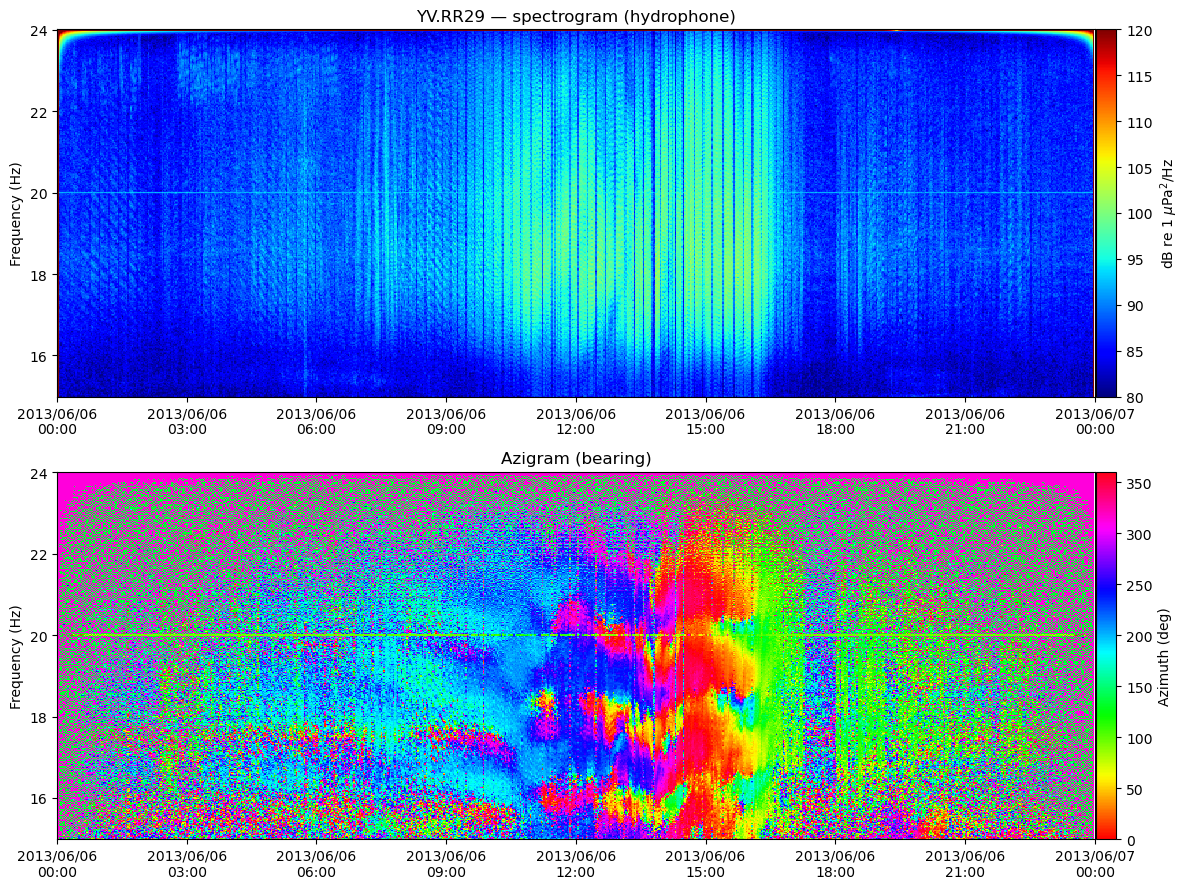

In [7]:
# --- azigram figure (level + bearing) ---
fig = plt.figure(figsize=(12, 9))
ax = plt.subplot(211)
im = ax.pcolormesh(t, f, level, cmap='jet', vmin=80, vmax=120)
cax = make_axes_locatable(ax).append_axes('right', size='2%', pad=0.01)
fig.colorbar(im, cax=cax).set_label(r"dB re 1 $\mu$Pa$^2$/Hz")
ax.set_ylabel('Frequency (Hz)'); ax.set_title(f'{net}.{sta} — spectrogram (hydrophone)')
ax.xaxis.set_major_formatter(date_format); ax.set_xlim(dt1, dt2)

ax = plt.subplot(212)
im = ax.pcolormesh(t, f, bearing, cmap='hsv', vmin=0, vmax=360)
cax = make_axes_locatable(ax).append_axes('right', size='2%', pad=0.01)
fig.colorbar(im, cax=cax).set_label("Azimuth (deg)")
ax.set_ylabel('Frequency (Hz)'); ax.set_title('Azigram (bearing)')
ax.xaxis.set_major_formatter(date_format); ax.set_xlim(dt1, dt2)
plt.tight_layout(); plt.show()

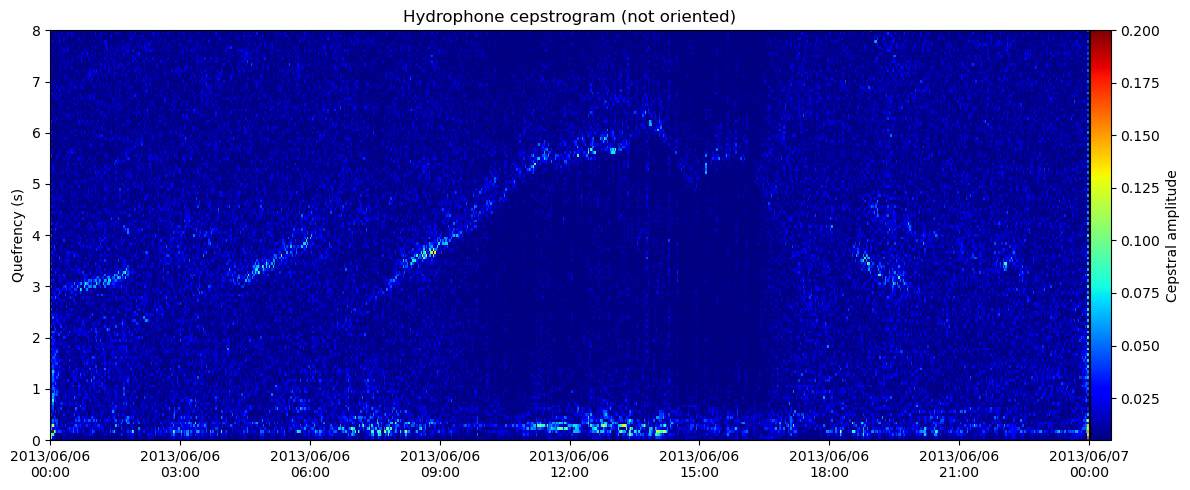

In [8]:
# --- hydrophone cepstrogram figure ---
fig = plt.figure(figsize=(12, 5))
ax = plt.subplot()
im = ax.pcolormesh(tc, q, np.abs(cepstro), cmap='jet', vmin=0.005, vmax=0.2)
cax = make_axes_locatable(ax).append_axes('right', size='2%', pad=0.01)
fig.colorbar(im, cax=cax).set_label("Cepstral amplitude")
ax.set_ylabel('Quefrency (s)'); ax.set_title('Hydrophone cepstrogram (not oriented)')
ax.xaxis.set_major_formatter(date_format); ax.set_xlim(dt1, dt2); ax.set_ylim(0, 8)
plt.tight_layout(); plt.show()

## 1) Azimuth extraction (initial method)

Mask the low-SNR time/frequency bins (relative to the median level), then run
the DBSCAN-based `get_sources_azimuths`, which returns one azimuth track per
detected source.

In [9]:
level_thr = 6.0          # dB above the median level to keep a bin

lvl = level.copy()
bear = bearing.copy()
elev = elevation.copy()
bkg = np.nanmedian(lvl)
drop = (lvl - bkg) < level_thr
lvl = np.where(drop, np.nan, lvl)
bear = np.where(drop, np.nan, bear)
elev = np.where(drop, np.nan, elev)

df_az = get_sources_azimuths(pd.to_datetime(t), f, lvl, bear, elev)
print(f"{0 if df_az.shape[0]==0 else df_az.index.nunique()} azimuth source(s)")
df_az.head()

41 azimuth source(s)


/Users/admin/Documents/science_workspace/STUDIES_BOKSOUND/ICI_detector_demo/lib/azimuthEstimateTools.py:112: RuntimeWarning: Mean of empty slice
  az_along_time_axis = np.nanmean(source_bearing, axis=0)
/Users/admin/Documents/science_workspace/STUDIES_BOKSOUND/ICI_detector_demo/lib/azimuthEstimateTools.py:112: RuntimeWarning: Mean of empty slice
  az_along_time_axis = np.nanmean(source_bearing, axis=0)
/Users/admin/Documents/science_workspace/STUDIES_BOKSOUND/ICI_detector_demo/lib/azimuthEstimateTools.py:112: RuntimeWarning: Mean of empty slice
  az_along_time_axis = np.nanmean(source_bearing, axis=0)
/Users/admin/Documents/science_workspace/STUDIES_BOKSOUND/ICI_detector_demo/lib/azimuthEstimateTools.py:112: RuntimeWarning: Mean of empty slice
  az_along_time_axis = np.nanmean(source_bearing, axis=0)
/Users/admin/Documents/science_workspace/STUDIES_BOKSOUND/ICI_detector_demo/lib/azimuthEstimateTools.py:112: RuntimeWarning: Mean of empty slice
  az_along_time_axis = np.nanmean(source_be

,time,freq,level,az,datetime
id_source,,,,,
0,1370529525975383616,15.966797,93.926981,345.800701,2013-06-06 14:38:45.975383616
0,1370529525975383616,16.037109,94.689499,345.800701,2013-06-06 14:38:45.975383616
0,1370529525975383616,16.054688,96.274384,345.800701,2013-06-06 14:38:45.975383616
0,1370529525975383616,16.072266,94.051755,345.800701,2013-06-06 14:38:45.975383616
0,1370525881847944576,16.089844,94.635228,281.501137,2013-06-06 13:38:01.847944576


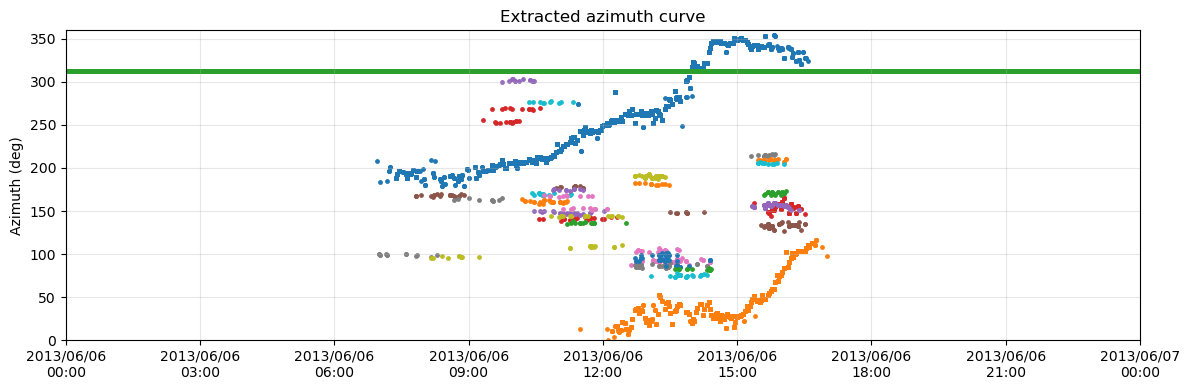

In [10]:
# --- azimuth curve ---
fig, ax = plt.subplots(figsize=(12, 4))
if df_az.shape[0]:
    n_src = df_az.index.nunique()
    for sid, g in df_az.groupby(df_az.index):
        ax.scatter(g['datetime'], g['az'], s=6,
                   label=(f'source {sid}' if n_src <= 10 else None))
    if n_src <= 10:
        ax.legend(loc='upper right', fontsize=8)
ax.set_ylabel('Azimuth (deg)'); ax.set_ylim(0, 360)
ax.set_title('Extracted azimuth curve'); ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(date_format); ax.set_xlim(dt1, dt2)
plt.tight_layout(); plt.show()

## 2) Distance extraction (initial method)

Cluster the cepstral peaks (`process_clustering_cepstro`), then convert each
measured quefrency into a candidate source distance with the flat-bottom image
model, accumulate the ray-pair hypotheses into a distance×time likelihood, and
take its ridge as the distance curve.

In [11]:
# Geometry from the station (sensor on the seafloor): depth = -elevation.
# (the station table may hold several rows per station -> take the first)
ele_val = dfstations.loc[sta, 'ele']
ele = float(ele_val.iloc[0] if hasattr(ele_val, 'iloc') else ele_val)
water_depth = abs(ele)
sensor_depth = abs(ele)
sound_speed = 1500.0
max_rebounds = 5
dist_min, dist_max, dist_res = 0.0, 50000.0, 100.0
quef_resolution = float(q[1] - q[0])
print(f"water_depth={water_depth:.0f} m, c={sound_speed} m/s, quef_res={quef_resolution:.4f} s")

water_depth=4829 m, c=1500.0 m/s, quef_res=0.0556 s


In [12]:
# Cepstral-peak clustering -> quefrency picks.
df_q = process_clustering_cepstro(tc, q, np.abs(cepstro), thr=12, kernel_size=21)
df_q = df_q[(df_q['quef'] > 1) & (df_q['quef'] < 8)]
print(f"{len(df_q)} cepstral picks")

# Quefrency -> candidate distances (image model) + distance/time likelihood.
df_dist, lst_ref = get_source_possible_distances(
    df_q, max_rebounds, dist_min, dist_max, tc, dist_res, quef_resolution,
    water_depth, sensor_depth, sound_speed)

dist_scale = np.arange(dist_min, dist_max, dist_res)
matrix_layer = get_distance_matrix_per_ref(df_dist, dist_scale, tc)
dist_matrix = np.nansum(matrix_layer, axis=0)
best_distance = dist_scale[np.nanargmax(dist_matrix, axis=0)]

1495 cepstral picks


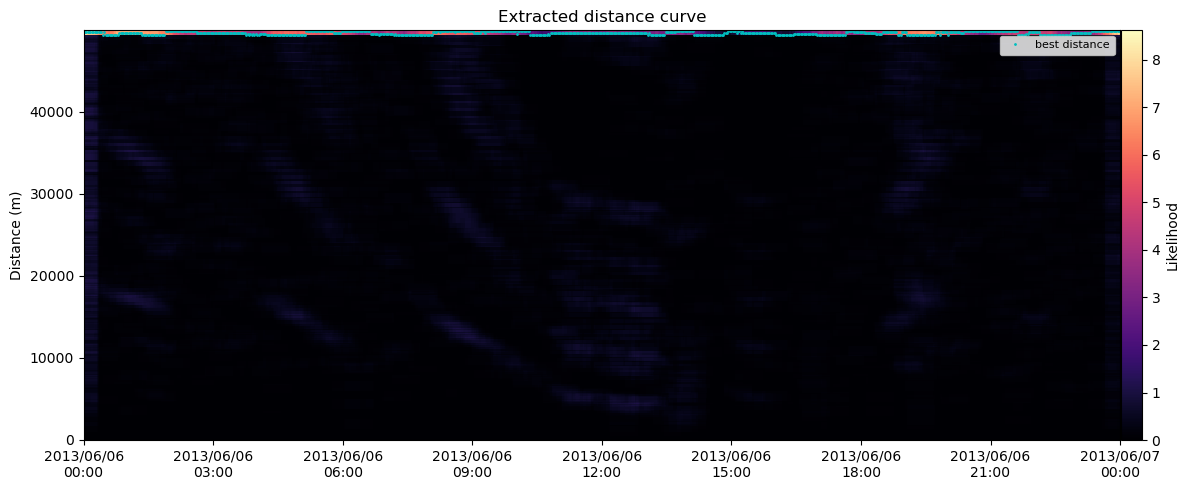

In [13]:
# --- distance figure: likelihood + ridge ---
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.pcolormesh(tc, dist_scale, dist_matrix, cmap='magma', shading='auto')
ax.plot(tc, best_distance, 'c.', markersize=2, label='best distance')
cax = make_axes_locatable(ax).append_axes('right', size='2%', pad=0.01)
fig.colorbar(im, cax=cax).set_label("Likelihood")
ax.set_ylabel('Distance (m)'); ax.set_title('Extracted distance curve')
ax.legend(loc='upper right', fontsize=8)
ax.xaxis.set_major_formatter(date_format); ax.set_xlim(dt1, dt2)
plt.tight_layout(); plt.show()

## Summary — azimuth curve & distance curve

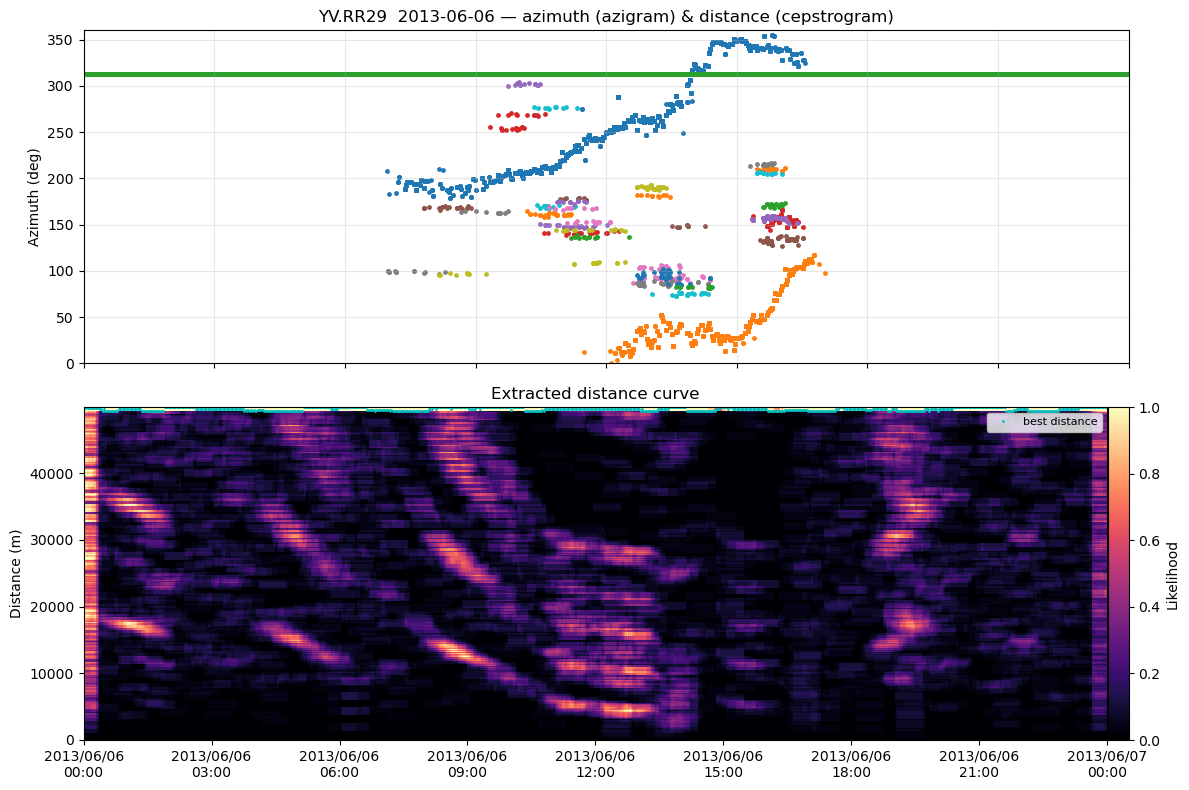

In [16]:
fig, (axa, ax) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
if df_az.shape[0]:
    n_src = df_az.index.nunique()
    for sid, g in df_az.groupby(df_az.index):
        axa.scatter(g['datetime'], g['az'], s=6,
                    label=(f'source {sid}' if n_src <= 10 else None))
    if n_src <= 10:
        axa.legend(loc='upper right', fontsize=8)
axa.set_ylabel('Azimuth (deg)'); axa.set_ylim(0, 360); axa.grid(alpha=0.3)
axa.set_title(f'{net}.{sta}  {dt1:%Y-%m-%d} — azimuth (azigram) & distance (cepstrogram)')

im = ax.pcolormesh(tc, dist_scale, dist_matrix, cmap='magma', shading='auto', vmin=0,vmax=1)
ax.plot(tc, best_distance, 'c.', markersize=2, label='best distance')
cax = make_axes_locatable(ax).append_axes('right', size='2%', pad=0.01)
fig.colorbar(im, cax=cax).set_label("Likelihood")
ax.set_ylabel('Distance (m)'); ax.set_title('Extracted distance curve')
ax.legend(loc='upper right', fontsize=8)
ax.xaxis.set_major_formatter(date_format); ax.set_xlim(dt1, dt2)
plt.tight_layout(); plt.show()